# Bowel Sound Detection — exp14: WavLM-Base with AS_1 Validation Split

**Based on exp11 v2.** Key change: use AS_1 **first 15%** as validation set instead of 23M74M.

**Why?** In exp11, ReduceLROnPlateau / early stopping / checkpoint selection all
optimised on 23M74M — the OOD test set. This leaks test-set signal into training decisions.

**Fix:** Temporal split of AS_1:
- Val    → AS_1 first 15%  (never seen during training; drives all scheduler/stopping)
- Train  → AS_1 last  85%  (with MIN_POS_FRAMES filter)
- OOD    → 23M74M (full file, evaluated only after training is complete)

**Model:** `microsoft/wavlm-base`  (~94 M params, 12 transformer layers, hidden=768)

**Architecture:**
```
raw waveform  (B, 64 000)           SR=16 kHz, 4 s per chunk
      |
  [CNN Feature Extractor]            7 conv layers, stride=320 — always frozen
  conv_stride = [5,2,2,2,2,2,2]  ->  stride product = 320 -> 50 fps
      |  (B, 199, 512)
  [Feature Projection]               Linear(512, 768) + LayerNorm — frozen P1
      |  (B, 199, 768)
  [12 x WavLM Transformer Layers]    Phase 1: frozen | Phase 2: top-4 unfrozen
  (gated relative position bias)
      |  (B, 199, 768)
  [Linear Head]
  Linear(768,256) -> GELU -> Dropout -> Linear(256,4)
      |  (B, 199, 4)                 logits: h / mb / sb / bg
```

## 1 · Install Dependencies

In [ ]:
import sys, os
from pathlib import Path

try:
    import google.colab; COLAB = True
    REPO_DIR = '/content/bowel-sound'
    if not os.path.exists(REPO_DIR):
        os.system(f'git clone https://github.com/medmabcf/bowel-sound.git  {REPO_DIR}')
    os.chdir(REPO_DIR)
    os.system('pip install -q transformers huggingface_hub librosa scikit-learn soundfile')
except ImportError:
    COLAB = False

print('Environment:', 'Colab' if COLAB else 'Local')
print('Working dir:', os.getcwd())

Environment: Colab
Working dir: /content/bowel-sound-detection


## 2 · Imports

In [2]:
import random
import os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import librosa
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.cuda.amp import autocast, GradScaler
from torch.utils.data import Dataset, DataLoader
from pathlib import Path
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import f1_score
from scipy.signal import medfilt
from transformers import (
    WavLMModel,                  # microsoft/wavlm-base
    Wav2Vec2FeatureExtractor,    # same normaliser — works for WavLM too
)
import huggingface_hub
warnings.filterwarnings('ignore')

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')
print(f'CUDA memory: {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB'
      if torch.cuda.is_available() else 'CPU only')

Device: cuda
CUDA memory: 15.6 GB


## 3 · HuggingFace Auth & Configuration

In [3]:
SEED = 42

def set_seed(seed):
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark     = False

set_seed(SEED)

try:
    from google.colab import userdata
    HF_TOKEN = userdata.get('HF_TOKEN') or ''
except Exception:
    HF_TOKEN = os.environ.get('HF_TOKEN', '')

if not HF_TOKEN:
    import getpass
    print("No HuggingFace token found.")
    print("Both models are public — you can skip this and still run the notebook.")
    print("To create a free token: https://huggingface.co/settings/tokens (Read access)")
    HF_TOKEN = getpass.getpass("Paste your HF token and press Enter (or just press Enter to skip): ").strip()
    if HF_TOKEN:
        print("Token set for this session.")
    else:
        print("No token — continuing without login (public models only).")

if HF_TOKEN:
    huggingface_hub.login(token=HF_TOKEN, add_to_git_credential=False)
    print("HF login: OK")

MODEL_ID = 'microsoft/wavlm-base'

if COLAB:
    DATA_SUBDIR = Path('/content/bowel-sound-detection/bowel-data')
    CKPT_DIR    = Path('/content/checkpoints_v14_wavlm_as1val')
else:
    DATA_SUBDIR = Path('bowel-data')
    CKPT_DIR    = Path('checkpoints_v14_wavlm_as1val')
CKPT_DIR.mkdir(parents=True, exist_ok=True)

OOD_AUDIO     = DATA_SUBDIR / '23M74M.wav'
AS1_VAL_AUDIO = DATA_SUBDIR / 'AS_1.wav'
OOD_LABEL     = DATA_SUBDIR / '23M74M.txt'
AS1_VAL_LABEL = DATA_SUBDIR / 'AS_1.txt'
AUDIO_FILES   = [OOD_AUDIO, AS1_VAL_AUDIO]
LABEL_FILES   = [OOD_LABEL, AS1_VAL_LABEL]

SR             = 16000
WAV2VEC_STRIDE = 320
FRAME_DUR      = WAV2VEC_STRIDE / SR
CHUNK_DUR      = 4.0
CHUNK_SAMPLES  = int(CHUNK_DUR * SR)
CHUNK_STRIDE   = 2.0
STRIDE_SAMPLES = int(CHUNK_STRIDE * SR)
N_FRAMES_CHUNK = 199
MIN_POS_FRAMES = 2

BATCH_SIZE      = 8
EPOCHS          = 150
PHASE1_EPOCHS   = 10
UNFREEZE_LAYERS = 4
PHASE2_LR_ENC   = 5e-6
PHASE2_LR_HEAD  = 1e-4
LR_HEAD         = 5e-4
WEIGHT_DECAY    = 5e-4
CLIP_GRAD       = 1.0
PATIENCE        = 25

CONF_THRESH    = 0.5
MIN_EVENT_DUR  = 0.020
MERGE_GAP      = 0.08
SMOOTH_WIN     = 5
SMOOTH_WIN_PER_CLASS = {'sb': 3, 'mb': 5, 'h': 7, 'bg': 5}
EVAL_IOU       = 0.3

TARGET_LABELS = ['h', 'mb', 'sb']
BG_LABEL      = 'bg'
ALL_LABELS    = TARGET_LABELS + [BG_LABEL]
N_CLASSES     = len(ALL_LABELS)
CLASS_TO_IDX  = {l: i for i, l in enumerate(ALL_LABELS)}
IDX_TO_CLASS  = {i: l for l, i in CLASS_TO_IDX.items()}
BG_IDX        = CLASS_TO_IDX[BG_LABEL]
ALIAS_MAP     = {'b':'sb','sbs':'sb','SB':'sb','mbs':'mb','MB':'mb','H':'h','harmonic':'h'}
CLASS_NAMES   = ALL_LABELS
VAL_SPLIT     = 0.15

print(f'MODEL:  {MODEL_ID}')
print(f'Data:   {DATA_SUBDIR}')
print(f'Ckpts:  {CKPT_DIR}')

No HuggingFace token found.
Both models are public — you can skip this and still run the notebook.
To create a free token: https://huggingface.co/settings/tokens (Read access)
Paste your HF token and press Enter (or just press Enter to skip): ··········
Token set for this session.
HF login: OK
MODEL:  microsoft/wavlm-base
Data:   /content/bowel-sound-detection/bowel-data
Ckpts:  /content/checkpoints_v14_wavlm_as1val


## 4 · Load Annotations & Frame-Level Labels

In [4]:
def load_annotations(txt_path):
    df = pd.read_csv(txt_path, sep='\t', header=None,
                     names=['start', 'end', 'label'])
    df['label'] = df['label'].str.strip().replace(ALIAS_MAP)
    df = df[df['label'].isin(TARGET_LABELS)].copy()
    df['duration'] = df['end'] - df['start']
    return df.reset_index(drop=True)


def make_frame_labels(ann_df, audio_dur):
    n_frames = int(np.ceil(audio_dur / FRAME_DUR)) + 1
    labels   = np.full(n_frames, BG_IDX, dtype=np.int64)
    for _, ann in ann_df.iterrows():
        s = max(0, int(ann['start'] / FRAME_DUR))
        e = min(n_frames, int(ann['end']   / FRAME_DUR) + 1)
        labels[s:e] = CLASS_TO_IDX[ann['label']]
    return labels


ann_23  = load_annotations(LABEL_FILES[0])
ann_as1 = load_annotations(LABEL_FILES[1])

print('Event counts after cleaning:')
for name, df in [('23M74M', ann_23), ('AS_1', ann_as1)]:
    print(f'  {name}: {dict(df["label"].value_counts())}  (total {len(df)})')

Event counts after cleaning:
  23M74M: {'sb': np.int64(255), 'mb': np.int64(230), 'h': np.int64(29)}  (total 514)
  AS_1: {'sb': np.int64(858), 'mb': np.int64(774), 'h': np.int64(80)}  (total 1712)


## 5 · Raw-Waveform Chunk Building

**exp14 change vs exp11:** AS_1 is split temporally:
- `split='val'`   → **first 15%** of AS_1 (val set — 400 events, 72 ev/min; drives LR scheduler, early stop, checkpoint)
- `split='train'` → **last 85%** of AS_1 (train set, with MIN_POS_FRAMES filter)
- 23M74M → `split='all'`, loaded **only** for final OOD evaluation after training

Why first 15%? The last 15% of AS_1 has only 34 events (6 ev/min) — far too sparse
for a reliable val F1. The first 15% has 400 events (72 ev/min) — much more stable signal.

In [5]:
def chunk_stats(chunks, label=''):
    total = len(chunks)
    pos   = sum(1 for c in chunks if c['n_pos'] > 0)
    all_lbl = np.concatenate([c['labels'] for c in chunks])
    dist = {IDX_TO_CLASS[i]: int((all_lbl == i).sum()) for i in range(N_CLASSES)}
    print(f'  {label}: {total} chunks | {pos} with events | {dist}')


def build_chunks_from_file(audio_path, ann_df, split='all'):
    y, _ = librosa.load(str(audio_path), sr=SR, mono=True)
    audio_dur = len(y) / SR
    print(f'  Loaded {Path(audio_path).name}: {audio_dur:.1f}s at {SR} Hz')

    # Frame-level labels for the full file
    n_frames_full = int(len(y) / WAV2VEC_STRIDE)
    frame_lbl = make_frame_labels(ann_df, audio_dur)
    if len(frame_lbl) > n_frames_full:
        frame_lbl = frame_lbl[:n_frames_full]
    elif len(frame_lbl) < n_frames_full:
        frame_lbl = np.pad(frame_lbl, (0, n_frames_full - len(frame_lbl)),
                           constant_values=BG_IDX)

    # Temporal split
    total_samples = len(y)
    if split in ('all', 'test'):
        s_start, s_end = 0, total_samples
    elif split == 'val':
        s_start = 0
        s_end   = int(total_samples * VAL_SPLIT)         # first 15%
    elif split == 'train':
        s_start = int(total_samples * VAL_SPLIT)         # last 85%
        s_end   = total_samples
    else:
        raise ValueError(split)

    chunks, s = [], s_start
    while s + CHUNK_SAMPLES <= s_end:
        wav_sl = y[s : s + CHUNK_SAMPLES]                 # (64 000,)
        f_s = s // WAV2VEC_STRIDE
        f_e = (s + CHUNK_SAMPLES) // WAV2VEC_STRIDE
        lbl_sl = frame_lbl[f_s:f_e]
        n_frames_chunk = CHUNK_SAMPLES // WAV2VEC_STRIDE
        if len(lbl_sl) < n_frames_chunk:
            lbl_sl = np.pad(lbl_sl, (0, n_frames_chunk - len(lbl_sl)),
                            constant_values=BG_IDX)
        chunks.append({
            'wav':    wav_sl.astype(np.float32),
            'labels': lbl_sl[:n_frames_chunk],
            'n_pos':  int((lbl_sl != BG_IDX).sum()),
            'file':   Path(audio_path).name,
        })
        s += STRIDE_SAMPLES

    print(f'  -> {len(chunks)} chunks ({split})')
    return chunks


# ── Validation: AS_1 first 15% — held-out, never influences training decisions ──
# (first 15% has 400 events at 72 ev/min; last 15% has only 34 events — too sparse)
print('Building validation chunks from AS_1 (first 15%) ...')
val_chunks = build_chunks_from_file(AUDIO_FILES[1], ann_as1, split='val')

# ── Training: AS_1 last 85% ───────────────────────────────────────────────
print('\nBuilding training chunks from AS_1 (last 85%) ...')
as1_train_raw = build_chunks_from_file(AUDIO_FILES[1], ann_as1, split='train')
train_chunks  = [c for c in as1_train_raw if c['n_pos'] >= MIN_POS_FRAMES]
dropped = len(as1_train_raw) - len(train_chunks)
print(f'AS_1 train: {len(as1_train_raw)} -> {len(train_chunks)} kept ({dropped} sparse dropped)')

# ── OOD test: 23M74M — NOT used during training ───────────────────────────
print('\nLoading 23M74M for OOD evaluation only ...')
all_23_chunks = build_chunks_from_file(AUDIO_FILES[0], ann_23, split='all')

print()
chunk_stats(val_chunks,   'Val   (AS_1 first 15%)')
chunk_stats(train_chunks, 'Train (AS_1 last  85%)')
chunk_stats(all_23_chunks,'OOD   (23M74M — eval only)')

Building validation chunks from AS_1 (first 15%) ...
  Loaded AS_1.wav: 2212.4s at 16000 Hz
  -> 164 chunks (val)

Building training chunks from AS_1 (last 85%) ...
  Loaded AS_1.wav: 2212.4s at 16000 Hz
  -> 939 chunks (train)
AS_1 train: 939 -> 553 kept (386 sparse dropped)

Loading 23M74M for OOD evaluation only ...
  Loaded 23M74M.wav: 300.6s at 16000 Hz
  -> 149 chunks (all)

  Val   (AS_1 first 15%): 164 chunks | 153 with events | {'h': 1330, 'mb': 7924, 'sb': 3144, 'bg': 20402}
  Train (AS_1 last  85%): 553 chunks | 553 with events | {'h': 5218, 'mb': 29471, 'sb': 10134, 'bg': 65777}
  OOD   (23M74M — eval only): 149 chunks | 149 with events | {'h': 1692, 'mb': 8928, 'sb': 2318, 'bg': 16862}


## 6 · Dataset

Raw waveform augmentation: additive Gaussian noise + random gain shift.

In [6]:
def seed_worker(worker_id):
    """Ensure each DataLoader worker uses a deterministic seed."""
    worker_seed = torch.initial_seed() % 2**32
    np.random.seed(worker_seed)
    random.seed(worker_seed)


def _make_coloured_noise(n, colour='white'):
    """Generate n samples of white, pink, or brown (red) noise."""
    white = np.random.randn(n).astype(np.float32)
    if colour == 'white':
        return white / (white.std() + 1e-9)
    freqs = np.fft.rfftfreq(n)
    freqs[0] = 1e-10   # avoid division-by-zero at DC
    power = 1.0 / np.sqrt(freqs) if colour == 'pink' else 1.0 / freqs
    spec  = np.fft.rfft(white) * power
    out   = np.fft.irfft(spec, n=n).astype(np.float32)
    return out / (out.std() + 1e-9)


class WaveformDataset(Dataset):
    def __init__(self, chunks, augment=False):
        self.chunks  = chunks
        self.augment = augment

    def __len__(self): return len(self.chunks)

    def __getitem__(self, i):
        c   = self.chunks[i]
        wav = c['wav'].copy().astype(np.float32)   # (CHUNK_SAMPLES,)
        if self.augment:
            # ── 1. Pitch shift ±4 semitones (50% prob) ───────────────────
            if np.random.rand() < 0.5:
                n_steps = np.random.uniform(-4, 4)
                wav = librosa.effects.pitch_shift(wav, sr=SR, n_steps=n_steps)
            # ── 3. Random gain ±3 dB ─────────────────────────────────────
            gain = 10 ** (np.random.uniform(-0.3, 0.3) / 20)
            wav  = wav * gain
            # ── 4. Coloured noise: white / pink / brown ───────────────────
            noise_type = np.random.choice(['white', 'pink', 'brown'])
            snr   = np.random.uniform(20, 40)   # dB
            noise = _make_coloured_noise(len(wav), noise_type)
            alpha = (wav.std() / (noise.std() + 1e-9)) * 10**(-snr/20)
            wav   = wav + alpha * noise
        # ── Guard: pitch shift can produce NaN/inf on silent chunks ─────
        wav = np.nan_to_num(wav, nan=0.0, posinf=1.0, neginf=-1.0)
        # ── Z-score normalisation (always) ───────────────────────────────
        wav = (wav - wav.mean()) / (wav.std() + 1e-9)
        x = torch.FloatTensor(wav)
        y = torch.LongTensor(c['labels'])
        return x, y


train_ds = WaveformDataset(train_chunks, augment=True)
val_ds   = WaveformDataset(val_chunks,   augment=False)

_g = torch.Generator()
_g.manual_seed(SEED)
train_dl = DataLoader(train_ds, batch_size=BATCH_SIZE,
                      shuffle=True,  num_workers=2, pin_memory=True,
                      worker_init_fn=seed_worker, generator=_g)
val_dl   = DataLoader(val_ds,   batch_size=BATCH_SIZE,
                      shuffle=False, num_workers=2, pin_memory=True)

print(f'Train batches: {len(train_dl)}  |  Val batches: {len(val_dl)}')

Train batches: 70  |  Val batches: 21


## 7 · Model — WavLM-Base + Frame Classifier

In [7]:
class BowelSSL(nn.Module):
    def __init__(self, model_id=MODEL_ID, n_classes=N_CLASSES, dropout=0.1):
        super().__init__()
        print(f'Loading {model_id} ...')
        self.encoder = WavLMModel.from_pretrained(
            model_id,
            token=HF_TOKEN or None,
            mask_time_prob=0.0,
            mask_feature_prob=0.0,
        )
        self.encoder.gradient_checkpointing_enable()
        print('Gradient checkpointing: enabled')

        hidden   = self.encoder.config.hidden_size          # 768
        n_layers = self.encoder.config.num_hidden_layers    # 12
        print(f'hidden_size={hidden}  |  num_layers={n_layers}')

        self.dropout = nn.Dropout(dropout)
        self.head = nn.Sequential(
            nn.Linear(hidden, 256),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(256, n_classes),
        )

    def forward(self, input_values):
        out    = self.encoder(input_values=input_values,
                              output_hidden_states=False)
        hidden = out.last_hidden_state   # (B, 199, 768)
        return self.head(self.dropout(hidden))   # (B, 199, 4)


model = BowelSSL().to(DEVICE)
n_total = sum(p.numel() for p in model.parameters())
print(f'Total params: {n_total/1e6:.1f} M')

feature_extractor = Wav2Vec2FeatureExtractor.from_pretrained(
    MODEL_ID, token=HF_TOKEN or None)

def normalize_batch(wav_batch):
    processed = feature_extractor(
        [w.numpy() for w in wav_batch],
        sampling_rate=SR, return_tensors='pt', padding='longest',
    )
    return processed.input_values   # (B, 64 000)

print('Model and feature extractor ready.')

Loading microsoft/wavlm-base ...


config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/378M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/247 [00:00<?, ?it/s]

WavLMModel LOAD REPORT from: microsoft/wavlm-base
Key               | Status     |  | 
------------------+------------+--+-
masked_spec_embed | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


model.safetensors:   0%|          | 0.00/378M [00:00<?, ?B/s]

Gradient checkpointing: enabled
hidden_size=768  |  num_layers=12
Total params: 94.6 M


preprocessor_config.json:   0%|          | 0.00/215 [00:00<?, ?B/s]

Model and feature extractor ready.


## 8 · Freeze / Unfreeze Helpers

In [8]:
def freeze_all():
    for p in model.encoder.parameters():
        p.requires_grad = False
    n = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f'Phase 1: entire WavLM encoder frozen. Trainable: {n:,} (head only)')


def unfreeze_top_layers(n_layers=UNFREEZE_LAYERS):
    layers = model.encoder.encoder.layers   # 12 WavLM transformer layers
    total  = len(layers)
    for layer in layers[total - n_layers:]:
        for p in layer.parameters():
            p.requires_grad = True
    for p in model.encoder.encoder.layer_norm.parameters():
        p.requires_grad = True
    n = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f'Phase 2: top {n_layers}/{total} WavLM transformer layers + layer_norm unfrozen.')
    print(f'  Trainable: {n/1e6:.2f} M params')


def make_optimizer(phase=1):
    if phase == 1:
        return torch.optim.AdamW(
            model.head.parameters(), lr=LR_HEAD, weight_decay=WEIGHT_DECAY)
    enc_params = [p for p in model.encoder.encoder.parameters()
                  if p.requires_grad]
    return torch.optim.AdamW([
        {'params': enc_params,               'lr': PHASE2_LR_ENC},
        {'params': model.head.parameters(),  'lr': PHASE2_LR_HEAD},
    ], weight_decay=WEIGHT_DECAY)


freeze_all()

Phase 1: entire WavLM encoder frozen. Trainable: 197,892 (head only)


## 9 · Loss Function

In [9]:
all_train_labels = np.concatenate([c['labels'] for c in train_chunks])
cls_weights = compute_class_weight(
    'balanced', classes=np.arange(N_CLASSES), y=all_train_labels)
cls_weights = np.clip(cls_weights, 0.1, 20.0)  # raised cap: h is rare (5%), needs stronger weight
cls_weights_t = torch.FloatTensor(cls_weights).to(DEVICE)
print('Class weights:', {IDX_TO_CLASS[i]: round(float(w), 3)
                         for i, w in enumerate(cls_weights)})


class FocalLoss(nn.Module):
    def __init__(self, gamma=2.0, weight=None, label_smoothing=0.05):
        super().__init__()
        self.gamma = gamma
        self.weight = weight
        self.label_smoothing = label_smoothing

    def forward(self, inputs, targets):
        ce = F.cross_entropy(inputs, targets, weight=self.weight,
                             label_smoothing=self.label_smoothing,
                             reduction='none')
        pt = torch.exp(-ce)
        return ((1.0 - pt) ** self.gamma * ce).mean()


criterion     = FocalLoss(gamma=2.0, weight=cls_weights_t, label_smoothing=0.05)
POS_LABEL_IDS = [CLASS_TO_IDX[l] for l in TARGET_LABELS]
print(f'Positive labels for early stopping: {TARGET_LABELS} -> {POS_LABEL_IDS}')

Class weights: {'h': 5.299, 'mb': 0.938, 'sb': 2.728, 'bg': 0.42}
Positive labels for early stopping: ['h', 'mb', 'sb'] -> [0, 1, 2]


## 10 · Training Loop

**exp14:** ReduceLROnPlateau monitors **AS_1 val F1** (first 15%, 400 events) — not 23M74M.
Early stopping and best-checkpoint saving also based on AS_1 val F1.
23M74M is never seen during training.

In [10]:
BEST_CKPT = CKPT_DIR / 'best_wavlm_as1val.pt'
scaler    = GradScaler()


def run_epoch(loader, train=True):
    model.train() if train else model.eval()
    total_loss = 0.0
    all_preds, all_true = [], []

    for xb, yb in loader:
        xb_norm = normalize_batch(xb).to(DEVICE)  # (B, 64 000)
        yb = yb.to(DEVICE)

        if train:
            optimizer.zero_grad()
            with autocast():
                logits  = model(xb_norm)           # (B, 199, 4)
                B, T, C = logits.shape
                yb_trim = yb[:, :T]                # align labels → T frames
                loss    = criterion(logits.reshape(-1, C), yb_trim.reshape(-1))
            if not torch.isfinite(loss):
                print(f'  WARNING: non-finite loss={loss.item():.4f}, skipping batch')
                optimizer.zero_grad()
                continue   # do NOT call scaler.update() before scaler.scale()
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            nn.utils.clip_grad_norm_(model.parameters(), CLIP_GRAD)
            scaler.step(optimizer)
            scaler.update()
        else:
            with torch.no_grad(), autocast():
                logits  = model(xb_norm)
                B, T, C = logits.shape
                yb_trim = yb[:, :T]
                loss    = criterion(logits.reshape(-1, C), yb_trim.reshape(-1))

        total_loss += loss.item() * B
        preds = logits.argmax(-1).reshape(-1).cpu().numpy()
        true  = yb_trim.reshape(-1).cpu().numpy()
        all_preds.extend(preds.tolist())
        all_true.extend(true.tolist())

    acc    = float((np.array(all_preds) == np.array(all_true)).mean())
    pos_f1 = f1_score(all_true, all_preds, average='macro',
                      labels=POS_LABEL_IDS, zero_division=0)
    return total_loss / len(loader.dataset), acc, pos_f1


def make_scheduler(optimizer):
    return torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode='max',
        factor=0.5,
        patience=5,
        min_lr=1e-7,
    )


history = {k: [] for k in ['tl','vl','ta','va','tf','vf','phase','lr']}
best_f1    = -1.0
no_improve = 0
current_phase = 1
optimizer = make_optimizer(phase=1)
scheduler = make_scheduler(optimizer)

for ep in range(1, EPOCHS + 1):

    if ep == PHASE1_EPOCHS + 1 and current_phase == 1:
        print(f'\n--- Phase 2 at epoch {ep}: unfreezing top {UNFREEZE_LAYERS} layers ---')
        unfreeze_top_layers(UNFREEZE_LAYERS)
        optimizer = make_optimizer(phase=2)
        scheduler = make_scheduler(optimizer)
        current_phase = 2

    tl, ta, tf = run_epoch(train_dl, train=True)
    vl, va, vf = run_epoch(val_dl,   train=False)
    scheduler.step(vf)   # ReduceLROnPlateau monitors AS_1 val F1 only

    cur_lr = optimizer.param_groups[0]['lr']
    for k, v in zip(['tl','vl','ta','va','tf','vf'], [tl,vl,ta,va,tf,vf]):
        history[k].append(v)
    history['phase'].append(current_phase)
    history['lr'].append(cur_lr)

    is_best = vf > best_f1
    if is_best:
        best_f1    = vf
        no_improve = 0
        torch.save({'epoch': ep, 'model_state_dict': model.state_dict(),
                    'best_val_f1': best_f1, 'history': history}, BEST_CKPT)
    else:
        no_improve += 1

    print(f'Ep {ep:3d} [P{current_phase}] | '
          f'train loss={tl:.4f} acc={ta:.3f} f1={tf:.3f} | '
          f'val(AS1) loss={vl:.4f} acc={va:.3f} f1={vf:.3f} '
          f'lr={cur_lr:.1e}'
          f'{" *" if is_best else ""}')

    if no_improve >= PATIENCE:
        print(f'Early stopping at epoch {ep}')
        break

print(f'\nBest val positive-class F1: {best_f1:.4f}')

Ep   1 [P1] | train loss=0.7869 acc=0.303 f1=0.247 | val(AS1) loss=0.6653 acc=0.250 f1=0.290 lr=5.0e-04 *
Ep   2 [P1] | train loss=0.6792 acc=0.401 f1=0.307 | val(AS1) loss=0.6545 acc=0.400 f1=0.287 lr=5.0e-04
Ep   3 [P1] | train loss=0.6721 acc=0.457 f1=0.332 | val(AS1) loss=0.6476 acc=0.274 f1=0.273 lr=5.0e-04
Ep   4 [P1] | train loss=0.6422 acc=0.449 f1=0.345 | val(AS1) loss=0.6631 acc=0.373 f1=0.327 lr=5.0e-04 *
Ep   5 [P1] | train loss=0.6397 acc=0.439 f1=0.330 | val(AS1) loss=0.6391 acc=0.396 f1=0.360 lr=5.0e-04 *
Ep   6 [P1] | train loss=0.6316 acc=0.469 f1=0.357 | val(AS1) loss=0.6199 acc=0.317 f1=0.280 lr=5.0e-04
Ep   7 [P1] | train loss=0.6147 acc=0.465 f1=0.356 | val(AS1) loss=0.6251 acc=0.289 f1=0.308 lr=5.0e-04
Ep   8 [P1] | train loss=0.6192 acc=0.481 f1=0.362 | val(AS1) loss=0.6206 acc=0.327 f1=0.328 lr=5.0e-04
Ep   9 [P1] | train loss=0.6276 acc=0.489 f1=0.364 | val(AS1) loss=0.6242 acc=0.399 f1=0.315 lr=5.0e-04
Ep  10 [P1] | train loss=0.6278 acc=0.477 f1=0.350 | val(A

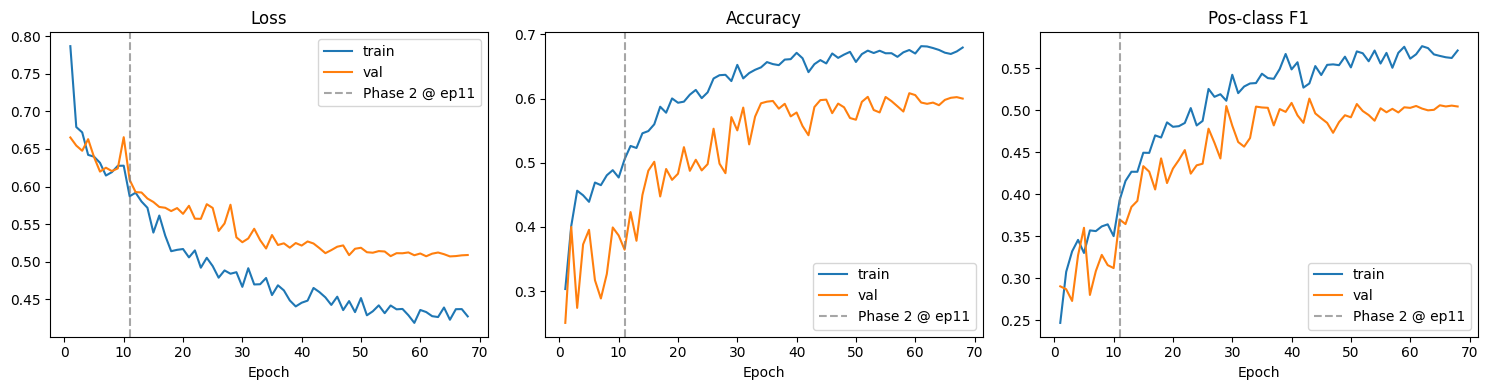

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
eps = range(1, len(history['tl']) + 1)
p2_start = next((i+1 for i,p in enumerate(history['phase']) if p==2), None)
for ax, (tk, vk, title) in zip(axes,
        [('tl','vl','Loss'),('ta','va','Accuracy'),('tf','vf','Pos-class F1')]):
    ax.plot(eps, history[tk], label='train')
    ax.plot(eps, history[vk], label='val')
    if p2_start:
        ax.axvline(p2_start, color='gray', ls='--', alpha=0.7, label=f'Phase 2 @ ep{p2_start}')
    ax.set_title(title); ax.set_xlabel('Epoch'); ax.legend()
plt.tight_layout()
plt.savefig(str(CKPT_DIR / 'curves_v14.png'), dpi=120)
plt.show()

## 11 · Inference & OOD Evaluation on 23M74M

23M74M was held out completely during training — the model has never seen it,
and no training decision (LR, early stopping, checkpoint) was based on it.
This gives a clean out-of-distribution (OOD) evaluation.

We also evaluate on the AS_1 val split (first 15%, same domain, held-out) for comparison:
a large gap between AS_1-val F1 and 23M74M F1 reveals domain shift.

In [12]:
ckpt = torch.load(str(BEST_CKPT), map_location=DEVICE, weights_only=False)
model.load_state_dict(ckpt['model_state_dict'])
print(f'Loaded epoch {ckpt["epoch"]} | val F1={ckpt["best_val_f1"]:.4f}')


def infer_full_audio(audio_path):
    """Chunked sliding-window inference."""
    y, _ = librosa.load(str(audio_path), sr=SR, mono=True)
    n_frames_total = len(y) // WAV2VEC_STRIDE
    prob_sum   = np.zeros((n_frames_total, N_CLASSES), dtype=np.float32)
    prob_count = np.zeros(n_frames_total, dtype=np.float32)
    model.eval()
    s = 0; n_chunks = 0
    while s + CHUNK_SAMPLES <= len(y):
        chunk = y[s : s + CHUNK_SAMPLES]
        inp   = feature_extractor([chunk], sampling_rate=SR,
                    return_tensors='pt', padding='longest').input_values.to(DEVICE)
        with torch.no_grad(), autocast():
            logits = model(inp)
            probs  = F.softmax(logits, dim=-1)[0].cpu().float().numpy()
        f_s = s // WAV2VEC_STRIDE
        f_e = min(f_s + probs.shape[0], n_frames_total)
        t   = f_e - f_s
        prob_sum[f_s:f_e]   += probs[:t]
        prob_count[f_s:f_e] += 1.0
        s += STRIDE_SAMPLES; n_chunks += 1
    print(f'  Ran {n_chunks} chunks over {len(y)/SR:.1f} s file')
    mask = prob_count > 0
    prob_sum[mask] /= prob_count[mask, None]
    return prob_sum


def frames_to_events(probs):
    """Convert per-frame probability array to event list."""
    pred_conf    = probs.max(axis=1)
    smooth_probs = probs.copy()
    for cls_idx in range(N_CLASSES):
        win = SMOOTH_WIN_PER_CLASS.get(IDX_TO_CLASS[cls_idx], SMOOTH_WIN)
        if win % 2 == 0: win += 1
        smooth_probs[:, cls_idx] = medfilt(probs[:, cls_idx], win)
    pred_smooth = smooth_probs.argmax(axis=1)
    pred_smooth[pred_conf < CONF_THRESH] = BG_IDX
    events, i, n = [], 0, len(pred_smooth)
    while i < n:
        cls = int(pred_smooth[i])
        if cls == BG_IDX: i += 1; continue
        j = i
        while j < n and pred_smooth[j] == cls: j += 1
        events.append({'start': i*FRAME_DUR, 'end': j*FRAME_DUR,
                        'label': IDX_TO_CLASS[cls], 'conf': float(probs[i:j,cls].mean())})
        i = j
    events = [e for e in events if (e['end']-e['start']) >= MIN_EVENT_DUR]
    merged = []
    for ev in sorted(events, key=lambda e: e['start']):
        if merged and ev['label']==merged[-1]['label'] and (ev['start']-merged[-1]['end'])<MERGE_GAP:
            merged[-1]['end'] = ev['end']
        else:
            merged.append(dict(ev))
    return merged


def compute_iou(a_s, a_e, b_s, b_e):
    inter = max(0.0, min(a_e, b_e) - max(a_s, b_s))
    union = max(a_e, b_e) - min(a_s, b_s)
    return inter / union if union > 0 else 0.0


IOU_THRESHOLDS = [0.3, 0.5, 0.8]


def event_level_eval_multi(pred_events, ann_df, audio_dur_s, iou_thresholds=IOU_THRESHOLDS):
    """Evaluate at multiple IoU thresholds. Returns (results_dict, summary_dict)."""
    import numpy as np
    audio_dur_min = audio_dur_s / 60.0
    results = {}
    for iou_thresh in iou_thresholds:
        res = {l: {'TP':0,'FP':0,'FN':0,'onset_errs':[],'dur_ratios':[]} for l in TARGET_LABELS}
        matched = set()
        for pred in pred_events:
            best_iou, best_idx, best_lbl = 0, -1, None
            for idx, gt in ann_df.iterrows():
                iou = compute_iou(pred['start'], pred['end'], gt['start'], gt['end'])
                if iou >= iou_thresh and iou > best_iou and idx not in matched:
                    best_iou, best_idx, best_lbl = iou, idx, gt['label']
            if best_idx >= 0 and pred['label'] == best_lbl:
                gt_row = ann_df.loc[best_idx]
                res[pred['label']]['TP'] += 1
                res[pred['label']]['onset_errs'].append(abs(pred['start']-gt_row['start'])*1000)
                res[pred['label']]['dur_ratios'].append(
                    (pred['end']-pred['start']) / max(gt_row['end']-gt_row['start'], 1e-6))
                matched.add(best_idx)
            elif pred['label'] in res:
                res[pred['label']]['FP'] += 1
        for idx, gt in ann_df.iterrows():
            if idx not in matched and gt['label'] in res:
                res[gt['label']]['FN'] += 1
        rows = []
        for lbl in TARGET_LABELS:
            r = res[lbl]
            tp, fp, fn = r['TP'], r['FP'], r['FN']
            p  = tp/(tp+fp) if (tp+fp) else 0.0
            rc = tp/(tp+fn) if (tp+fn) else 0.0
            f1 = 2*p*rc/(p+rc) if (p+rc) else 0.0
            rows.append({'label':lbl,'P':p,'R':rc,'F1':f1,'TP':tp,'FP':fp,'FN':fn,
                         'FAR/min':round(fp/audio_dur_min,2),
                         'onset_ms':round(float(np.mean(r['onset_errs'])) if r['onset_errs'] else 0,1),
                         'dur_ratio':round(float(np.mean(r['dur_ratios'])) if r['dur_ratios'] else 0,2)})
        results[iou_thresh] = pd.DataFrame(rows).set_index('label')
    macro = {t: float(results[t]['F1'].mean()) for t in iou_thresholds}
    return results, {'macro_per_thresh': macro, 'mAP': float(np.mean(list(macro.values())))}


def print_multi_eval(results, summary, title, audio_dur_s):
    bar = '=' * 70
    print(f'\n{bar}\n  {title}   ({audio_dur_s/60:.1f} min)\n{bar}')
    for iou_t in sorted(results):
        df = results[iou_t]
        print(f'\n  IoU >= {iou_t}    macro F1 = {summary["macro_per_thresh"][iou_t]:.3f}')
        print('  ' + '-'*67)
        print('  ' + df[['P','R','F1','TP','FP','FN','FAR/min','onset_ms','dur_ratio']].round(3).to_string().replace('\n','\n  '))
    print(f'\n  mAP: {summary["mAP"]:.3f}\n{bar}')


print('\nRunning inference on 23M74M (OOD) ...')
probs_23  = infer_full_audio(OOD_AUDIO)
events_23 = frames_to_events(probs_23)
dur_23    = librosa.get_duration(path=str(OOD_AUDIO))
res_23, sum_23 = event_level_eval_multi(events_23, ann_23, dur_23)
print_multi_eval(res_23, sum_23, '23M74M OOD Test', dur_23)

print('\nRunning inference on AS_1 (val split) ...')
probs_as1   = infer_full_audio(AS1_VAL_AUDIO)
as1_dur     = librosa.get_duration(path=str(AS1_VAL_AUDIO))
val_end_t   = as1_dur * VAL_SPLIT
events_as1v = [e for e in frames_to_events(probs_as1) if e['end'] <= val_end_t]
ann_as1_val = ann_as1[ann_as1['end'] <= val_end_t].copy()
res_as1, sum_as1 = event_level_eval_multi(events_as1v, ann_as1_val, as1_dur*VAL_SPLIT)
print_multi_eval(res_as1, sum_as1, 'AS_1 Val (first 15%)', as1_dur*VAL_SPLIT)

print('\n── Domain gap ──')
for t in sorted(res_23.keys()):
    f1v = sum_as1['macro_per_thresh'][t]
    f1o = sum_23['macro_per_thresh'][t]
    print(f'  IoU={t}  AS1={f1v:.3f}  OOD={f1o:.3f}  gap={f1v-f1o:+.3f}')
print(f'  mAP   AS1={sum_as1["mAP"]:.3f}  OOD={sum_23["mAP"]:.3f}  gap={sum_as1["mAP"]-sum_23["mAP"]:+.3f}')

Loaded epoch 43 | val F1=0.5137

Running inference on 23M74M (OOD) ...
  Ran 149 chunks over 300.6 s file

  23M74M OOD Test   (5.0 min)

  IoU >= 0.3    macro F1 = 0.257
  -------------------------------------------------------------------
             P      R     F1  TP   FP   FN  FAR/min  onset_ms  dur_ratio
  label                                                                 
  h      0.417  0.345  0.377  10   14   19     2.79     116.0       1.01
  mb     0.328  0.083  0.132  19   39  211     7.78     263.6       0.95
  sb     0.206  0.353  0.260  90  346  165    69.06      33.3       1.86

  IoU >= 0.5    macro F1 = 0.163
  -------------------------------------------------------------------
             P      R     F1  TP   FP   FN  FAR/min  onset_ms  dur_ratio
  label                                                                 
  h      0.333  0.276  0.302   8   16   21     3.19     135.9       1.16
  mb     0.121  0.030  0.049   7   51  223    10.18      47.7       1.0